# Participantes

- 1220665 - Nuno Marinho
- 1221083 - Rodrigo Cardoso
- 1260464 - Raphael Moragas

# Project 1 — Classification of Abnormal Electric-Vehicle Charging Sessions

## 1. Context 
 
Electric-vehicle  charging  infrastructures  generate  large  volumes  of  operational  data.  Identifying  charging 
sessions at increased risk of abnormal termination can support preventive monitoring, charger maintenance, 
resource allocation, and service-quality improvement. 
 
In this project, you will develop and evaluate a classification solution for predicting whether an electric-vehicle 
charging session will terminate abnormally. 
 
Each group must design, justify, implement, and critically evaluate its own modelling solution. 
 
 
## 2. Prediction objective 
 
The objective is to predict the binary target: 
– is_Abnormal = 1: abnormal charging session; 
– is_Abnormal = 0: normal charging session. 
 
The prediction must represent a decision made when a charging session starts. Consequently, only information 
that would reasonably be available at that time may be used as a predictor. 
 
The project should answer the following general question: 
To what extent can contextual, operational, and historical information available at the beginning of a 
charging session be used to predict abnormal termination of a charging session? 
 
 
## 3. Available data 
 
The dataset provided for this project is an educational adaptation of the China EV Charging Dataset introduced 
by Zhang et al. (2025). The original dataset contains 441,077 charging transactions recorded over two years at 
13 public charging stations located in three districts of Jiaxing, China. 
 
The  project  dataset  retains  variables  describing  the  complete  charging  transaction,  including  information 
recorded at the beginning, during, and after the charging session. It also includes electricity-tariff information 
and  precomputed  historical  attributes  describing  previous  activity  and  abnormal  sessions  associated  with 
charging posts and users. 
 
The available variables are organised into the following groups. 
 
Session identification and location 
– UserID: identifier of the user associated with the transaction; 
– Charging Post ID: identifier of the charging post; 
– Location Information: charging-station location; 
– District Name: district in which the station is located. 
 
Charging-transaction information 
– Order creation time: date and time of the order charge 
– Transaction power/kWh: energy associated with the charging transaction; 
– Electricity cost/Yuan: cost of the electricity consumed; 
– Service charge/Yuan: service fee applied to the transaction; 
– Transaction Amount/Yuan: total transaction amount; 
– Actual Payment/Yuan: amount effectively paid; 
– Start Time: date and time at which the charging session started; 
– End Time: date and time at which the charging session ended; 
– Payment time: date and time at which payment was recorded; 
– End cause: reason why the charging session ended. 
 
Weather conditions 
– Temperature(°C): recorded temperature; 
– Relative Humidity(%): recorded relative humidity; 
– Precipitation(mm): recorded precipitation. 
 
Consider weather variables as estimates or forecasts available at the beginning of the charging session. 
 
Electricity-tariff information 
– electricity_price: electricity price applicable at the session start time; 
– tariff_period: tariff interval determined by the session start time. 
 
The dataset contains precomputed attributes describing previous activity at the same charging post and at 
the same user, including: 
 
Historical charging-post information 
• numbers of previous completed sessions over different temporal windows;  
• numbers and smoothed rates of previous completed abnormal sessions;  
• time since the previous completed session;  
• time since the previous completed abnormal session;  
• indicators identifying posts without previous completed-session or abnormal-session history.  
 
Historical user/account information 
– is new user 
– numbers of previous completed sessions over different temporal windows;  
– numbers and smoothed rates of previous completed abnormal sessions;  
– time since the previous completed session;  
– time since the previous completed abnormal session;  
– indicators identifying new users/accounts and accounts without completed-session history;  
– number of other sessions associated with the same account that were active when the current session 
started.

Earlier-started sessions that remained active at the prediction time were excluded from all outcome-derived 
historical attributes. Their outcomes were not yet available. Concurrent activity is represented separately 
through user_active_sessions_at_start, which uses only start and end timestamps available at the prediction 
time. 
 
Historical attributes were constructed chronologically to prevent the current session or future sessions from 
contributing information to the current predictors. Students are not required to reconstruct these variables, 
but they must: 
– understand their meaning; 
– evaluate their contribution through feature-group ablation; 
– consider whether they would be operationally available at prediction time; 
– discuss their implications for privacy, generalisation, and cold-start cases. 
 
 
## 4. Main tasks 
 
Task 1 — Understand, audit, and prepare the data 
 
Conduct a systematic and critical analysis of the supplied data before developing the classification models. 
The objective is to understand the dataset, identify factors that may affect modelling, and define a justified 
data-preparation strategy. 
 
As guidance, the analysis may include aspects such as data types and variable meanings, missing values, 
duplicated or inconsistent observations, temporal coverage, target-class distribution, numerical distributions, 
potential outliers, categorical cardinality, rare categories, relationships between variables, temporal changes, 
and possible data-quality problems. These examples are not exhaustive. 
 
Potential data-quality problems must be investigated before corrective action is taken. Decisions to retain, 
transform, impute, group, cap, or remove observations must be supported by evidence and by the meaning 
of the corresponding variables. 
 
Explore the data using appropriate numerical summaries and graphical representations. Figures should be 
selected to answer relevant analytical questions and must be interpreted in the report. A collection of plots 
without an explanation of their meaning, modelling implications, or relationship to the project objective will 
not be considered an adequate exploratory analysis. 
 
The exploratory analysis should consider whether important properties of the data change over time. In 
particular, investigate whether session volume, class prevalence, predictor distributions, user or charging-
post activity, and other relevant patterns remain stable throughout the observation period. Explain how any 
identified temporal changes may affect model development and evaluation. 
 
Any preparation operation that learns information from the data—including imputation, scaling, category 
grouping, outlier thresholds, resampling, feature selection, or dimensionality reduction represent different 
methodological reasons and must be documented separately.  
At the end of this task, provide a concise synthesis identifying: 
– the most important characteristics and problems discovered in the data; 
– the evidence supporting the adopted preparation decisions; 
– the variables or variable groups retained for modelling; 
– unresolved limitations or assumptions; 
– the expected implications for model selection and evaluation. 
 
The quality of this task will be assessed through the relevance and depth of the investigation, the justification 
of decisions, and the interpretation of evidence—not by the number of statistics, figures, or preprocessing 
operations presented. 
 
 
Each weekly submission should include the corresponding notebook and a concise report section explaining 
decisions, evidence, results, and conclusions—not merely describing the code. 
The report should focus on reasoning, evidence, and critical analysis. It should not reproduce sections of source 
code. 
 
 
References 
 
Zhang, Y., Xu, T., Chen, T., et al. (2025). A high-resolution electric vehicle charging transaction dataset with 
multidimensional features in China. Scientific Data, 12, 643. https://doi.org/10.1038/s41597-025-04982-1

# Task 1 — Compreensão, auditoria e preparação dos dados

## 1. Carregamento e visão geral

In [878]:
import pandas as pd

file_path = r"C:\Users\Raphael\Desktop\Mineração de Dados\Minera-o_de_Dados_MEI\data\Charging_Data_educational.csv"
df = pd.read_csv(file_path)

In [879]:
df.head()

,UserID,Charging Post ID,Location Information,District Name,Order creation time,Transaction power/kwh,Electricity cost/Yuan,Service charge/Yuan,Transaction Amount/Yuan,Actual Payment/Yuan,...,user_previous_abnormal_180D,user_previous_abnormal_rate_180D,user_previous_sessions_730D,user_previous_abnormal_730D,user_previous_abnormal_rate_730D,user_days_since_previous_completed_session,user_no_previous_completed_session,user_days_since_previous_completed_abnormal,user_no_previous_completed_abnormal,user_active_sessions_at_start
0,11182,24,Shopping Mall,Tongxiang,2019-12-31 21:26:58\t,37.65,33.62,26.62,60.24,60.24,...,0,0.2,0,0,0.2,NaN,1,NaN,1,0
1,27510,67,Government Agency,Xiuzhou,2019-12-31 21:50:58\t,12.03,10.74,8.51,19.25,19.25,...,0,0.2,0,0,0.2,NaN,1,NaN,1,0
2,10877,45,Park B,Tongxiang,2019-12-31 22:19:34\t,44.04,39.33,31.14,70.47,70.47,...,0,0.2,0,0,0.2,NaN,1,NaN,1,0
3,11591,26,Shopping Mall,Tongxiang,2019-12-31 22:37:24\t,59.51,53.13,42.08,95.21,95.21,...,0,0.2,0,0,0.2,NaN,1,NaN,1,0
4,11425,53,Bus Station,Tongxiang,2019-12-31 23:32:28\t,26.19,23.39,18.52,41.91,41.91,...,0,0.2,0,0,0.2,NaN,1,NaN,1,0


In [880]:
df.columns

Index(['UserID', 'Charging Post ID', 'Location Information', 'District Name',
       'Order creation time', 'Transaction power/kwh', 'Electricity cost/Yuan',
       'Service charge/Yuan', 'Transaction Amount/Yuan', 'Actual Payment/Yuan',
       'Start Time', 'End Time', 'Payment time', 'Temperature(℃)',
       'Relative Humidity(%)', 'Precipitation(mm)', 'end_cause',
       'electricity_price', 'tariff_period', 'post_previous_sessions_1D',
       'post_previous_abnormal_1D', 'post_previous_abnormal_rate_1D',
       'post_previous_sessions_7D', 'post_previous_abnormal_7D',
       'post_previous_abnormal_rate_7D', 'post_previous_sessions_30D',
       'post_previous_abnormal_30D', 'post_previous_abnormal_rate_30D',
       'post_hours_since_previous_completed_session',
       'post_no_previous_completed_session',
       'post_hours_since_previous_completed_abnormal',
       'post_no_previous_completed_abnormal', 'is_new_user',
       'user_previous_sessions_30D', 'user_previous_abnormal_30

In [881]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 441077 entries, 0 to 441076
Data columns (total 47 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   UserID                                        441077 non-null  int64  
 1   Charging Post ID                              441077 non-null  int64  
 2   Location Information                          441077 non-null  str    
 3   District Name                                 441077 non-null  str    
 4   Order creation time                           441077 non-null  str    
 5   Transaction power/kwh                         441077 non-null  float64
 6   Electricity cost/Yuan                         441077 non-null  float64
 7   Service charge/Yuan                           441077 non-null  float64
 8   Transaction Amount/Yuan                       441077 non-null  float64
 9   Actual Payment/Yuan                           441077 non-nu

O dataset tem 441 077 linhas e 47 colunas. É possivel observar que 4 colunas de datas foram lidas como texto (`str`) e precisam de ser convertidas antes que possamos fazer qualquer tipo de conta com a mesma. Também é possivel observar que apenas 4 colunas têm valores ausentes, todas do grupo de atributos históricos.

## 2. Qualidade dos dados

### 2.1 Valores ausentes

In [882]:
na = df.isnull().sum()
print(na)

UserID                                               0
Charging Post ID                                     0
Location Information                                 0
District Name                                        0
Order creation time                                  0
Transaction power/kwh                                0
Electricity cost/Yuan                                0
Service charge/Yuan                                  0
Transaction Amount/Yuan                              0
Actual Payment/Yuan                                  0
Start Time                                           0
End Time                                             0
Payment time                                         0
Temperature(℃)                                       0
Relative Humidity(%)                                 0
Precipitation(mm)                                    0
end_cause                                            0
electricity_price                                    0
tariff_per

Sabemos então quantos valores faltam mas não o pq desses valores estarem faltando. Por exemplo: Se um usuário nunca teve uma falha ele terá NaN no seu estado e não há valor para se inventar nesse caso. O NaN por sí só já é a informação. 

In [883]:
# Os ausentes coincidem com as flags de "sem histórico anterior"?

pd.crosstab(df['post_hours_since_previous_completed_session'].isna(),
            df['post_no_previous_completed_session'])



post_no_previous_completed_session,0,1
post_hours_since_previous_completed_session,,
False,440985,0
True,0,92


In [884]:
# Verificando quantos postos diferentes existem
print(df["Charging Post ID"].nunique())

92


As linhas indicam se o valor está ausente (`True`) ou não (`False`); as colunas indicam a flag (`1` = o posto nunca teve uma sessão concluída antes).

- 440 985 sessões têm valor e o posto já tinha histórico (flag 0). É o esperado.
- 92 sessões têm NaN e o posto não tinha histórico (flag 1). É o esperado.
- As outras duas células são 0: não existe nenhum NaN num posto com histórico (False 1), nem nenhum valor preenchido num posto sem histórico (True 0).

Os 92 casos correspondem exatamente aos 92 postos do dataset, ou seja, na primeira sessão de cada posto, que não tem uma sessão anterior com que se comparar. O NaN é, portanto, estrutural e não um erro.

In [885]:
pd.crosstab(df['post_hours_since_previous_completed_abnormal'].isna(),
            df['post_no_previous_completed_abnormal'])

post_no_previous_completed_abnormal,0,1
post_hours_since_previous_completed_abnormal,,
False,440710,0
True,0,367


In [886]:
print(df["post_no_previous_completed_abnormal"].sum())

367


- 440 710 sessões têm valor e o posto já tinha tido pelo menos uma falha.
- 367 sessões têm NaN e o posto ainda não tinha registado nenhuma falha.
- Fora da diagonal, 0 casos.

As 367 sessões são as que ocorreram em cada posto antes da sua primeira falha. Sem uma falha anterior, não existe "tempo desde a última falha". Este NaN também é estrutural.

In [887]:
pd.crosstab(df['user_days_since_previous_completed_session'].isna(),
            df['user_no_previous_completed_session'])


user_no_previous_completed_session,0,1
user_days_since_previous_completed_session,,
False,384430,0
True,0,56647


In [888]:
print(df["UserID"].nunique())

56115


- 384 430 sessões têm valor e o usuário já tinha pelo menos uma sessão concluída.
- 56 647 sessões têm NaN e o usuário não tinha nenhuma sessão concluída antes.
- Fora da diagonal, 0 casos.

Destas 56 647, 56 115 são a primeira sessão de cada usuário (o dataset tem exatamente 56 115 usuários distintos). As restantes 532 são sessões iniciadas enquanto a primeira sessão do mesmo usuário ainda decorria: como o enunciado explica, sessões ainda ativas não contam como "concluídas", por isso continua a não existir uma sessão anterior concluída. 
Novamente os resultados acabam por ser um NaN estrutural e não precisamos modificar nada nas linhas.

In [889]:
pd.crosstab(df['user_days_since_previous_completed_abnormal'].isna(),
            df['user_no_previous_completed_abnormal'])

user_no_previous_completed_abnormal,0,1
user_days_since_previous_completed_abnormal,,
False,304798,0
True,0,136279


- 304 798 sessões têm valor e o usuário já tinha tido pelo menos uma falha.
- 136 279 sessões (~31%) têm NaN e o usuário nunca tinha tido uma falha.
- Fora da diagonal, 0 casos.

É a coluna com mais ausentes, o que faz sentido: muitos usuários têm poucas sessões e nunca passaram por uma falha. E, pela ultima vez, o NaN que encontramos aqui continua sendo estrutural.


### Conclusão e decisão para as 4 colunas: 

Em todos os casos, os valores ausentes coincidem exatamente com as flags `_no_previous_`. São apenas ausencias estruturais, não erros de registo. Por isso, não serão imputados com média ou mediana, porque isso inventaria um histórico inexistente e apagaria a diferença entre "falhou há muito tempo" e "nunca falhou".

### 2.2 Dados Duplicados

In [890]:
df.duplicated().sum()

np.int64(0)

Não existem linhas duplicadas no dataset, por isso não é necessária nenhuma ação.

### 2.3 Espaços escondidos no texto e conversão de datas

In [891]:
# De acordo com os valores que encotramos certas colunas que se refeream a datas
# acabam sendo lidas como string, então iremos coverter as mesmas
# para o tipo datetime, facilitando a manipulação dos dados.

date_cols = ['Order creation time', 'Start Time', 'End Time', 'Payment time']

df['Order creation time'] = pd.to_datetime(df['Order creation time'], errors='raise')
df['Start Time'] = pd.to_datetime(df['Start Time'], errors='raise')
df['End Time'] = pd.to_datetime(df['End Time'], errors='raise')
df['Payment time'] = pd.to_datetime(df['Payment time'], errors='raise')

In [892]:
# Datas convertidas; resolução interna em microssegundos (padrão do pandas), 
# suficiente para a análise.
df[date_cols].dtypes

Order creation time    datetime64[us]
Start Time             datetime64[us]
End Time               datetime64[us]
Payment time           datetime64[us]
dtype: object

In [893]:
# Precisamos verificar se não existe nenhuma anomalia de data/hora, 
# onde a data de fim de carregamneto é maior que a data de início.
# Com nenhum End < Start, podemos prosseguir com a análise.

start = df['Start Time']
end = df['End Time']

maiores = (end > start).sum()
iguais = (end == start).sum()
menores = (end < start).sum()

print(f"End > Start: {maiores}")
print(f"End = Start: {iguais}")
print(f"End < Start: {menores}")

# Ver as linhas problemáticas (end antes ou igual ao start)
df[end < start][['Start Time', 'End Time']]

End > Start: 441072
End = Start: 5
End < Start: 0


,Start Time,End Time


Apenas item com tipo object ou string podem ter um tab final escondido no meio do texto, como o tipo das datas já foram modificadas e perderam automaticamente o tab final iremos procurar nos outros itens que tenhas os tipos em que esse problema possa aparecer.

In [894]:
df['Location Information'].unique()

<StringArray>
[                'Shopping Mall',             'Government Agency',
                        'Park B',                   'Bus Station',
 'Expressway Service District B', 'Expressway Service District A',
 'Expressway Service District C',            'Tourist Attraction',
             'Industrial Park\t',                        'Park A',
     'Financial Industrial Park',               'Technology Park',
              'Wholesale Market']
Length: 13, dtype: str

In [895]:
df['Location Information'] = df['Location Information'].replace({"Industrial Park\t": "Industrial Park"})
df["Location Information"].unique()

<StringArray>
[                'Shopping Mall',             'Government Agency',
                        'Park B',                   'Bus Station',
 'Expressway Service District B', 'Expressway Service District A',
 'Expressway Service District C',            'Tourist Attraction',
               'Industrial Park',                        'Park A',
     'Financial Industrial Park',               'Technology Park',
              'Wholesale Market']
Length: 13, dtype: str

In [896]:
df['tariff_period'].unique()

<StringArray>
[    'peak_21_22', 'off_peak_22_24', 'off_peak_00_08',     'peak_08_11',
 'off_peak_11_13',     'peak_13_19',    'sharp_19_21']
Length: 7, dtype: str

In [897]:
df['District Name'].unique()

<StringArray>
['Tongxiang', 'Xiuzhou', 'Nanhu']
Length: 3, dtype: str

In [898]:
# Valores únicos
df['end_cause'].unique()

<StringArray>
[                                      'Charging ends normally',
                                          'User stops charging',
                                                  'BMS failure',
                                   'Faulty charging connection',
 'Failure of non-system control loop components and assemblies',
                               'Vehicle communications failure',
                            'Other faults of the charging pile',
                                              'DC Output Fault',
                                  'DC switching device failure',
                                      'Vehicle charging faults',
                                'System communications failure',
                                'Power conversion unit failure',
                                             'AC Input Failure',
                            'Vehicle Stake Interaction Failure',
                                  'AC switching device failure']
Length: 15,

Vemos então que nenhum item com o tipo object ou string tem mais erros de escrita que possam dividir resultados, trazendo incossitencia nos dados.

### 2.4 Consistência e valores extremos

In [899]:
# End < Start e Start < Order já foram verificados antes.
# Aqui verificamos só o pagamento: ele é registado depois do fim da sessão?
print('Payment < End:', (df['Payment time'] < df['End Time']).sum())

# Tamanho da diferença (em segundos) nos casos em que o pagamento vem antes do fim
dif_pag = (df['End Time'] - df['Payment time']).dt.total_seconds()
dif_pag[dif_pag > 0].describe()

Payment < End: 87202


count    87202.000000
mean        35.864063
std         35.157164
min          1.000000
25%          8.000000
50%         24.000000
75%         53.000000
max       1314.000000
dtype: float64

Em 87 202 sessões (~20%) o pagamento aparece registado antes do fim da sessão. Olhando a diferença entre os dois horários, ela é pequena (mediana de 24 segundos), então parece ser uma diferença de registo entre sistemas e não um erro grave, mas posso estar errado.

Como `Payment time` é uma coluna que só existe depois da sessão e não vai ser usada no modelo, não fazemos nenhuma correção. Fica só registado como uma inconsistência dos dados.

In [900]:
print('Total ≠ eletr. + serviço:',
      ((df['Electricity cost/Yuan'] + df['Service charge/Yuan']
        - df['Transaction Amount/Yuan']).abs() > 0.05).sum())          # 0
print('Pago > Total:',
      (df['Actual Payment/Yuan'] > df['Transaction Amount/Yuan'] + 0.01).sum())  # 0
print('kWh = 0:', (df['Transaction power/kwh'] == 0).sum())              # 54 621

Total ≠ eletr. + serviço: 0
Pago > Total: 0
kWh = 0: 54621


Os valores monetários são consistentes: em nenhuma sessão o total é diferente da soma de eletricidade + serviço, e em nenhuma o valor pago é maior que o total.

Existem 54 621 sessões (~12%) com 0 kWh carregados. Isto não é um erro, são sessões que terminaram sem carregar energia (na secção 4 vamos ver que a maioria delas é anormal). Por isso essas linhas são mantidas.

In [901]:
df[['Temperature(℃)', 'Relative Humidity(%)', 'Precipitation(mm)']].describe()

,Temperature(℃),Relative Humidity(%),Precipitation(mm)
count,441077.000000,441077.000000,441077.000000
mean,19.708336,75.030351,3.510698
std,8.481954,12.656150,10.833238
min,-3.200000,32.000000,0.000000
25%,12.700000,67.000000,0.000000
50%,21.000000,76.000000,0.000000
75%,26.900000,84.000000,1.200000
max,33.600000,99.000000,152.100000


Verificamos se os valores do clima fazem sentido para Jiaxing (leste da China, clima subtropical):

- Temperatura entre -3,2 °C e 33,6 °C: plausível para inverno e verão da região.
- Umidade entre 32% e 99%: dentro do intervalo possível (0–100%).
- Precipitação entre 0 e 152,1 mm: a maioria das sessões não tem chuva (a mediana é 0), e os valores mais altos podem ser dias de chuva forte ou tufão, que acontecem na região.

Nenhum valor parece impossível, então não removemos nem alteramos nada. Os valores mais altos de precipitação são extremos, mas reais.

In [902]:
# Quantos valores negativos existem em cada coluna numérica
negativos = (df.select_dtypes('number') < 0).sum()
print(negativos[negativos > 0])

# Em que meses aparecem as temperaturas negativas?
df.loc[df['Temperature(℃)'] < 0, 'Start Time'].dt.to_period('M').value_counts()

Temperature(℃)    2052
dtype: int64


Start Time
2020-12    2052
Freq: M, Name: count, dtype: int64

A única coluna numérica com valores negativos é a temperatura (2 052 sessões), e todos esses casos acontecem em dezembro de 2020, ou seja, no inverno. Temperaturas abaixo de zero são normais nessa época, então não é um erro.

Nenhuma outra coluna (energia, custos, contagens do histórico) tem valores negativos, o que era esperado porque não faria sentido.

**Conclusão da 2.4:** não encontramos inconsistências que exijam corrigir ou remover linhas. As pequenas diferenças de horário afetam apenas colunas que não vão entrar no modelo, e os valores extremos de clima (minimo e máxomo) são plausíveis para a região.

## 3. Definição da variável alvo

In [903]:
# Contagem de cada valor (do mais frequente ao menos frequente)
df['end_cause'].value_counts()

end_cause
Charging ends normally                                          203201
User stops charging                                             155942
Other faults of the charging pile                                20114
DC Output Fault                                                  14813
Vehicle communications failure                                   13936
Faulty charging connection                                        8539
BMS failure                                                       8170
Failure of non-system control loop components and assemblies      6941
Vehicle charging faults                                           6429
Power conversion unit failure                                     1653
DC switching device failure                                       1058
System communications failure                                      162
AC Input Failure                                                    99
Vehicle Stake Interaction Failure                                  

In [904]:
# Contagem + percentagem lado a lado
pd.DataFrame({
    'n': df['end_cause'].value_counts(),
    '%': (df['end_cause'].value_counts(normalize=True) * 100).round(2)
})

,n,%
end_cause,,
Charging ends normally,203201,46.07
User stops charging,155942,35.35
Other faults of the charging pile,20114,4.56
DC Output Fault,14813,3.36
Vehicle communications failure,13936,3.16
Faulty charging connection,8539,1.94
BMS failure,8170,1.85
Failure of non-system control loop components and assemblies,6941,1.57
Vehicle charging faults,6429,1.46


In [905]:
# Confirmação antes de construir o alvo: end_cause não tem valores ausentes
# (já verificado na secção 2.1), por isso todas as sessões recebem uma classe.
df['end_cause'].isna().sum()


np.int64(0)

In [906]:
normais = ['Charging ends normally', 'User stops charging']
df['is_Abnormal'] = (~df['end_cause'].isin(normais)).astype(int)

df['is_Abnormal'].value_counts(normalize=True)

is_Abnormal
0    0.814241
1    0.185759
Name: proportion, dtype: float64

Aproximadamente 81,5% dos carregamentos terminam de forma normal, apenas 18,5% terminam de forma anormal por algum problema ou do carro, ou do carregador.

Como a previsão deve ser feita no início da sessão, cada variável foi classificada segundo a sua disponibilidade nesse momento. As variáveis registadas durante ou após a sessão foram excluídas dos preditores para evitaro que se foi pedido no enunciado ("The prediction must represent a decision made when a charging session starts. Consequently, only information that would reasonably be available at that time may be used as a predictor"), sendo usadas apenas na análise exploratória.

Outro ponto importante é verificar as analises levando em conta que o ID tanto do posto quanto do usuário pode gerar enviseamento dos dados. O enunciado pede para usarmos com e sem esses IDs para verificar as diferenças nos resultados.

In [907]:
# Verificação antes de classificar 'Order creation time':
# o pedido é mesmo criado antes do início da sessão?
dif_seg = (df['Order creation time'] - df['Start Time']).dt.total_seconds()

print("Número de pedidos criados antes do início da sessão:")
print((dif_seg > 0).sum())
print("Diferença mediana nesses casos em segundos:")
print(dif_seg[dif_seg > 0].median())

Número de pedidos criados antes do início da sessão:
248588
Diferença mediana nesses casos em segundos:
55.0


In [908]:
inicio = {
    'Location Information': 'Local da estação, conhecido antes do início',
    'District Name': 'Distrito da estação, conhecido antes do início',
    'Start Time': 'Momento da previsão',
    'Temperature(℃)': 'Enunciado: considerar como previsão disponível no início',
    'Relative Humidity(%)': 'Enunciado: considerar como previsão disponível no início',
    'Precipitation(mm)': 'Enunciado: considerar como previsão disponível no início',
    'electricity_price': 'Determinado pela hora de início',
    'tariff_period': 'Determinado pela hora de início',
    'is_new_user': 'Conhecido pelo histórico da conta',
    'user_active_sessions_at_start': 'Usa só sessões ativas no início',
}

depois = {
    'Transaction power/kwh': 'Energia só é conhecida no fim',
    'Electricity cost/Yuan': 'Calculado a partir da energia consumida',
    'Service charge/Yuan': 'Calculado a partir da energia consumida',
    'Transaction Amount/Yuan': 'Total da transação, calculado no fim',
    'Actual Payment/Yuan': 'Pago após o fim',
    'End Time': 'Momento do término',
    'Payment time': 'Registrado após o fim',
    'end_cause': 'É a origem do alvo',
}

discutivel = {
    'UserID': 'Disponível, mas risco de decorar usuários; privacidade; não generaliza a novos usuários',
    'Charging Post ID': 'Disponível, mas risco de decorar postos; não generaliza a postos novos',
}

redundante = {
    'Order creation time': 'Em 56% das sessões é registado depois do Start Time '
                           '(mediana 55 s); redundante com Start Time',
}

# Variável que queremos prever (criada na secção 3 a partir de end_cause)
alvo = {
    'is_Abnormal': 'Variável a prever (1 = sessão anormal, 0 = normal)',
}

classificacao = pd.DataFrame({'coluna': df.columns})

# Valor por defeito: coluna não classificada (caso de segurança para pegar colunas esquecidas)
classificacao['disponibilidade'] = '?'
classificacao['justificativa'] = 'NÃO CLASSIFICADA'
classificacao['uso'] = '-'

# Atributos históricos (colunas que começam por post_ ou user_)
historico = classificacao['coluna'].str.startswith('post_') | classificacao['coluna'].str.startswith('user_')
classificacao.loc[historico, 'disponibilidade'] = 'Início'
classificacao.loc[historico, 'justificativa'] = 'Histórico calculado cronologicamente (enunciado)'
classificacao.loc[historico, 'uso'] = 'Feature'

# Disponíveis no início
linhas_inicio = classificacao['coluna'].isin(inicio.keys())
classificacao.loc[linhas_inicio, 'disponibilidade'] = 'Início'
classificacao.loc[linhas_inicio, 'justificativa'] = classificacao['coluna'].map(inicio)
classificacao.loc[linhas_inicio, 'uso'] = 'Feature'

# Só conhecidas depois do fim
linhas_depois = classificacao['coluna'].isin(depois.keys())
classificacao.loc[linhas_depois, 'disponibilidade'] = 'Depois do fim'
classificacao.loc[linhas_depois, 'justificativa'] = classificacao['coluna'].map(depois)
classificacao.loc[linhas_depois, 'uso'] = 'Só EDA'

# Discutíveis (IDs)
linhas_discutivel = classificacao['coluna'].isin(discutivel.keys())
classificacao.loc[linhas_discutivel, 'disponibilidade'] = 'Discutível'
classificacao.loc[linhas_discutivel, 'justificativa'] = classificacao['coluna'].map(discutivel)
classificacao.loc[linhas_discutivel, 'uso'] = 'A avaliar'

# Redundante
linhas_redundante = classificacao['coluna'].isin(redundante.keys())
classificacao.loc[linhas_redundante, 'disponibilidade'] = 'Redundante'
classificacao.loc[linhas_redundante, 'justificativa'] = classificacao['coluna'].map(redundante)
classificacao.loc[linhas_redundante, 'uso'] = 'Não usar'

# Alvo
linhas_alvo = classificacao['coluna'].isin(alvo.keys())
classificacao.loc[linhas_alvo, 'disponibilidade'] = 'Alvo'
classificacao.loc[linhas_alvo, 'justificativa'] = classificacao['coluna'].map(alvo)
classificacao.loc[linhas_alvo, 'uso'] = 'Alvo'

classificacao

,coluna,disponibilidade,justificativa,uso
0,UserID,Discutível,"Disponível, mas risco de decorar usuários; pri...",A avaliar
1,Charging Post ID,Discutível,"Disponível, mas risco de decorar postos; não g...",A avaliar
2,Location Information,Início,"Local da estação, conhecido antes do início",Feature
3,District Name,Início,"Distrito da estação, conhecido antes do início",Feature
4,Order creation time,Redundante,Em 56% das sessões é registado depois do Start...,Não usar
5,Transaction power/kwh,Depois do fim,Energia só é conhecida no fim,Só EDA
6,Electricity cost/Yuan,Depois do fim,Calculado a partir da energia consumida,Só EDA
7,Service charge/Yuan,Depois do fim,Calculado a partir da energia consumida,Só EDA
8,Transaction Amount/Yuan,Depois do fim,"Total da transação, calculado no fim",Só EDA
9,Actual Payment/Yuan,Depois do fim,Pago após o fim,Só EDA


A tabela acima classifica cada uma das 48 colunas (as 47 originais mais a `is_Abnormal` que criámos) segundo a pergunta: "este valor já é conhecido quando a sessão começa?"

- Início → Feature: informação conhecida no momento da previsão (localização, hora de início, clima, tarifa e atributos históricos). São as candidatas a preditores.

- Depois do fim → Só EDA: valores que só existem depois de a sessão terminar (energia, custos, hora de fim, pagamento e a própria causa de término). Se fossem usados, o modelo estaria a "ver o futuro" e teria um desempenho artificialmente alto. Ficam no dataset apenas para a análise exploratória.

- Discutível → A avaliar: os identificadores de usuário e posto. Estão disponíveis no início, mas podem levar o modelo a decorar IDs específicos, não funcionam para usuários ou postos novos, visto que os dados não existem na primeira vez de um usuário ou posto. A decisão será tomada comparando modelos com e sem estas colunas.

- Alvo: `is_Abnormal`, é a variável que tentaremos prever.

A última categoria do código (`?`) serve de verificação: se alguma coluna caísse aí, significaria que nos esquecemos de a classificar. Com o `is_Abnormal` agora classificado como alvo, nenhuma coluna fica por classificar.

In [909]:
print(classificacao['disponibilidade'].value_counts())

features_inicio = classificacao.loc[classificacao['uso'] == 'Feature', 'coluna'].tolist()
colunas_depois = classificacao.loc[classificacao['uso'] == 'Só EDA', 'coluna'].tolist()
colunas_ids = classificacao.loc[classificacao['uso'] == 'A avaliar', 'coluna'].tolist()


disponibilidade
Início           36
Depois do fim     8
Discutível        2
Redundante        1
Alvo              1
Name: count, dtype: int64


A partir da tabela, guardamos três listas que vão ser reutilizadas nas próximas etapas:
- `features_inicio`: colunas candidatas a preditores;
- `colunas_depois`: colunas que nunca entram no modelo, só na análise exploratória;
- `colunas_ids`: identificadores a testar com e sem, na fase de modelação.

Assim, a separação entre o que pode e o que não pode entrar no modelo fica definida num único sítio e não precisa de ser repetida à mão.

A célula seguinte mostra, com um exemplo concreto, porque é que as colunas pós-sessão têm de ficar de fora.

In [910]:
# Se kWh = 0 quase sempre é anormal, isso prova que a coluna "entrega" a resposta
df.groupby(df['Transaction power/kwh'] == 0)['is_Abnormal'].agg(['mean', 'count'])


,mean,count
Transaction power/kwh,,
False,0.094114,386456
True,0.834166,54621


Exemplo de problema nos dados: das 54 621 sessões com 0 kWh carregados, 83,4% são anormais. Nas sessões que contem energia carregada (> 0 kWh), só 9,4% são anormais.

Faz sentido: se a sessão falha logo no início, não chega a carregar energia. Mas a quantidade de energia só é conhecida depois de a sessão terminar. Se esta coluna entrasse no modelo, ele aprenderia a regra "0 kWh → anormal" e teria ótimos resultados no teste, mas seria inútil na prática, porque no momento da previsão esse valor ainda não existe, estariamos apenas jogando lixo para dentro de nossos dados.

Isto confirma, com evidência, e justifica nossa decisão de excluir dos preditores todas as colunas classificadas como "Depois do fim".

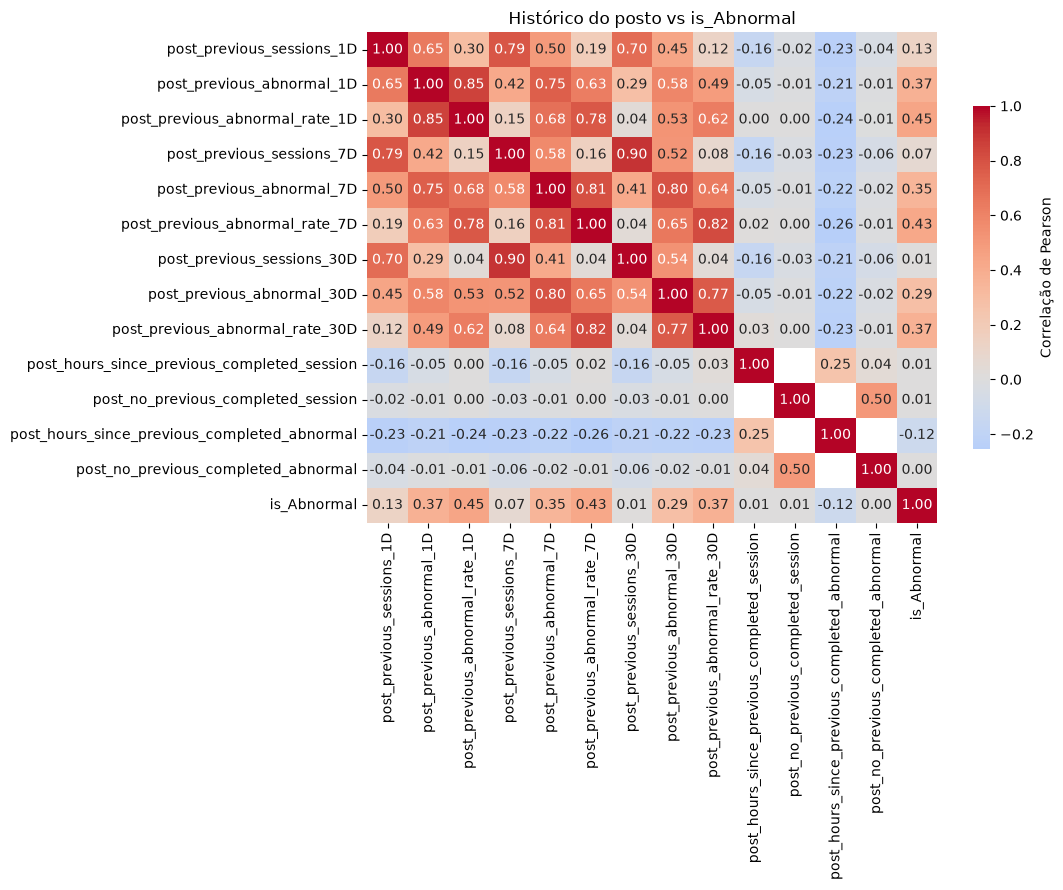

In [911]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Histórico do posto
cols_posto = ['post_previous_sessions_1D', 'post_previous_abnormal_1D', 'post_previous_abnormal_rate_1D',
              'post_previous_sessions_7D', 'post_previous_abnormal_7D', 'post_previous_abnormal_rate_7D',
              'post_previous_sessions_30D', 'post_previous_abnormal_30D', 'post_previous_abnormal_rate_30D',
              'post_hours_since_previous_completed_session', 'post_no_previous_completed_session',
              'post_hours_since_previous_completed_abnormal', 'post_no_previous_completed_abnormal']

corr_posto = df[cols_posto + ['is_Abnormal']].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_posto, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', cbar_kws={'label': 'Correlação de Pearson', 'shrink': 0.7})
plt.title('Histórico do posto vs is_Abnormal')
plt.tight_layout()
plt.show()

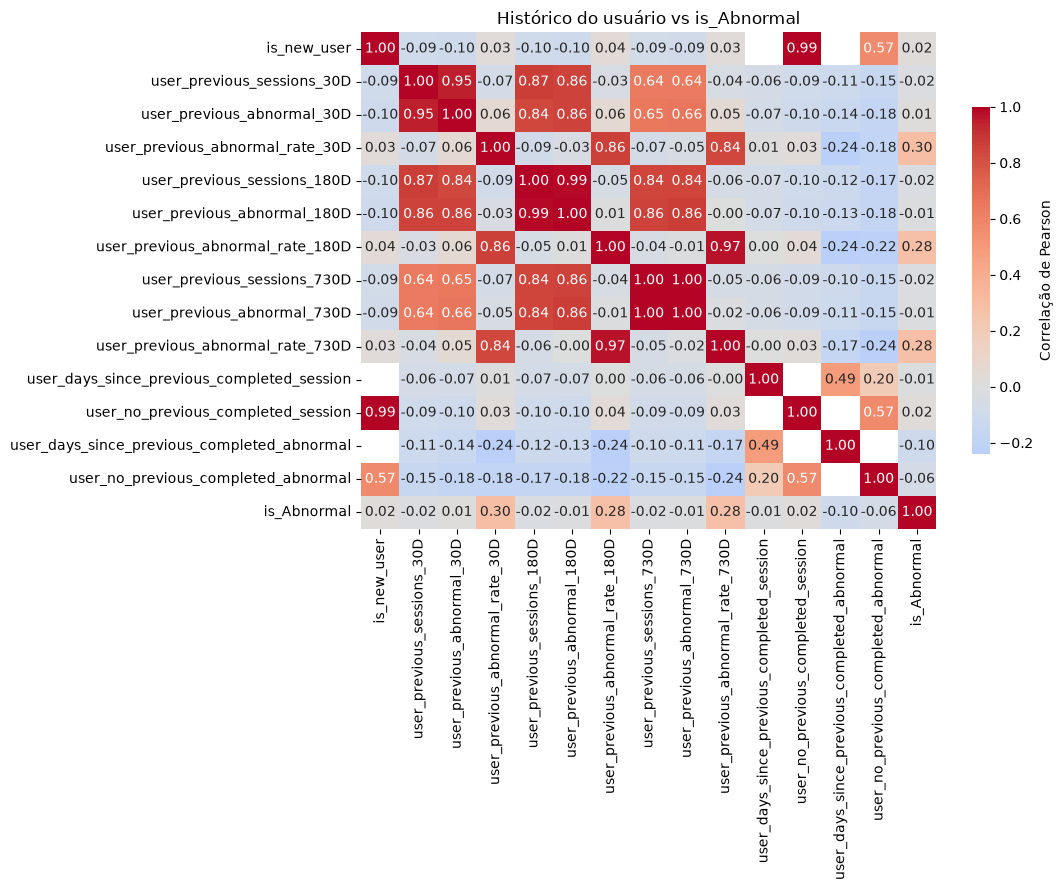

In [912]:
# 2. Histórico do usuário
# (user_active_sessions_at_start fica no contexto: não é histórico, são sessões ativas no momento)
cols_usuario = ['is_new_user',
                'user_previous_sessions_30D', 'user_previous_abnormal_30D', 'user_previous_abnormal_rate_30D',
                'user_previous_sessions_180D', 'user_previous_abnormal_180D', 'user_previous_abnormal_rate_180D',
                'user_previous_sessions_730D', 'user_previous_abnormal_730D', 'user_previous_abnormal_rate_730D',
                'user_days_since_previous_completed_session', 'user_no_previous_completed_session',
                'user_days_since_previous_completed_abnormal', 'user_no_previous_completed_abnormal']

corr_usuario = df[cols_usuario + ['is_Abnormal']].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_usuario, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', cbar_kws={'label': 'Correlação de Pearson', 'shrink': 0.7})
plt.title('Histórico do usuário vs is_Abnormal')
plt.tight_layout()
plt.show()

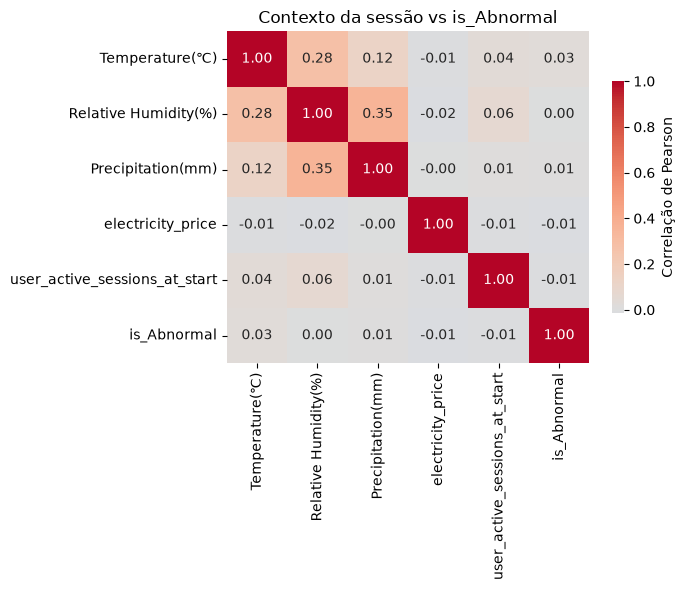

In [913]:
# 3. Contexto da sessão (clima, preço e sessões ativas do usuário no momento)
cols_contexto = ['Temperature(℃)', 'Relative Humidity(%)', 'Precipitation(mm)',
                 'electricity_price', 'user_active_sessions_at_start']

corr_contexto = df[cols_contexto + ['is_Abnormal']].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_contexto, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', cbar_kws={'label': 'Correlação de Pearson', 'shrink': 0.7})
plt.title('Contexto da sessão vs is_Abnormal')
plt.tight_layout()
plt.show()

In [914]:
# 4. Correlação de Pearson da localização e do período tarifário com is_Abnormal
# Transformamos cada categoria numa coluna 0/1 (one-hot), por exemplo "é Shopping Mall?".
# Não podemos usar 1, 2, 3... porque essa ordem seria inventada e mudaria o resultado.
dummies_local = pd.get_dummies(df['Location Information'], dtype=int)
dummies_periodo = pd.get_dummies(df['tariff_period'], dtype=int)

corr_local = dummies_local.corrwith(df['is_Abnormal']).sort_values().to_frame('is_Abnormal')
corr_periodo = dummies_periodo.corrwith(df['is_Abnormal']).to_frame('is_Abnormal')

# Normalização da escala de cor nos dois gráficos, para poderem ser comparados
# Sem isso um gráfico poderia ter cores mais fortes que o outro,
# mesmo que a correlação seja menor e vice versa.
limite = max(corr_local.abs().max().iloc[0], corr_periodo.abs().max().iloc[0])


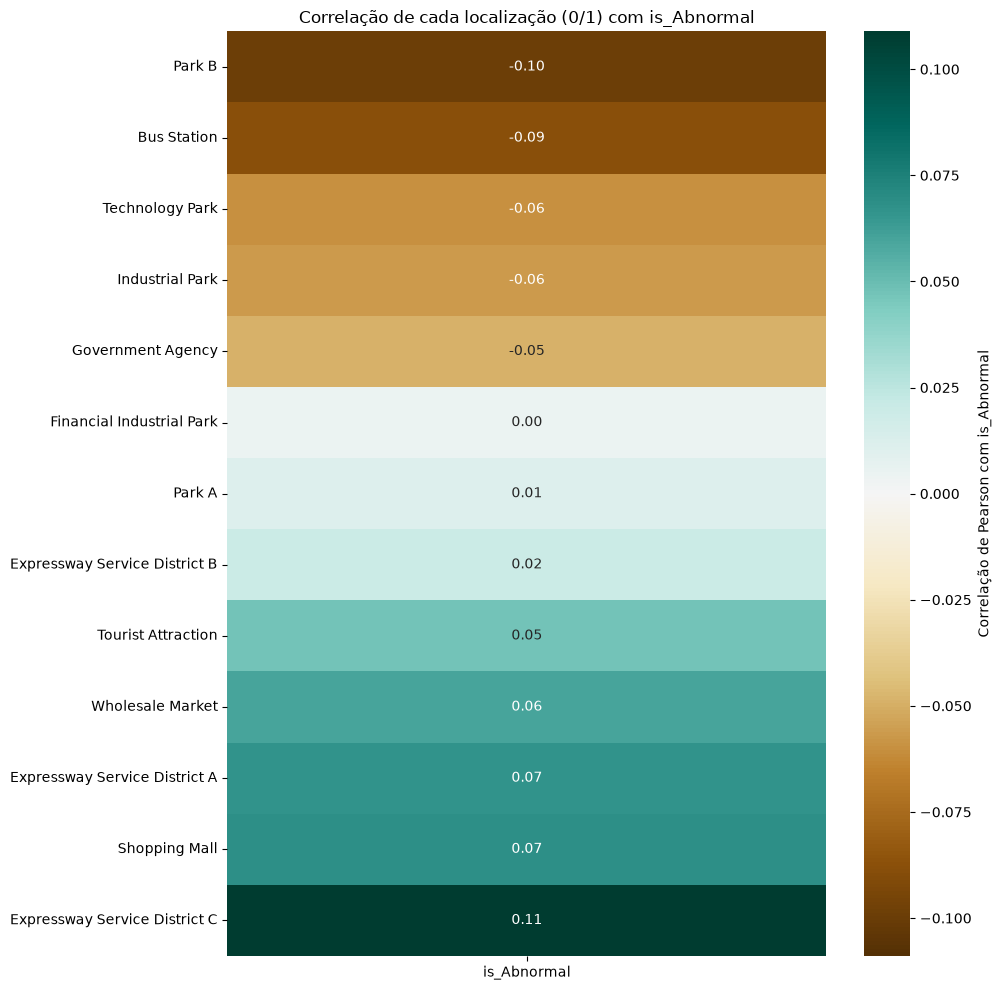

In [915]:
# 4a. Localização
plt.figure(figsize=(10, 10))
sns.heatmap(corr_local, cmap='BrBG', center=0, vmin=-limite, vmax=limite, annot=True, fmt='.2f', cbar_kws={'label': 'Correlação de Pearson com is_Abnormal'})
plt.title('Correlação de cada localização (0/1) com is_Abnormal')
plt.ylabel('')
plt.tight_layout()
plt.show()

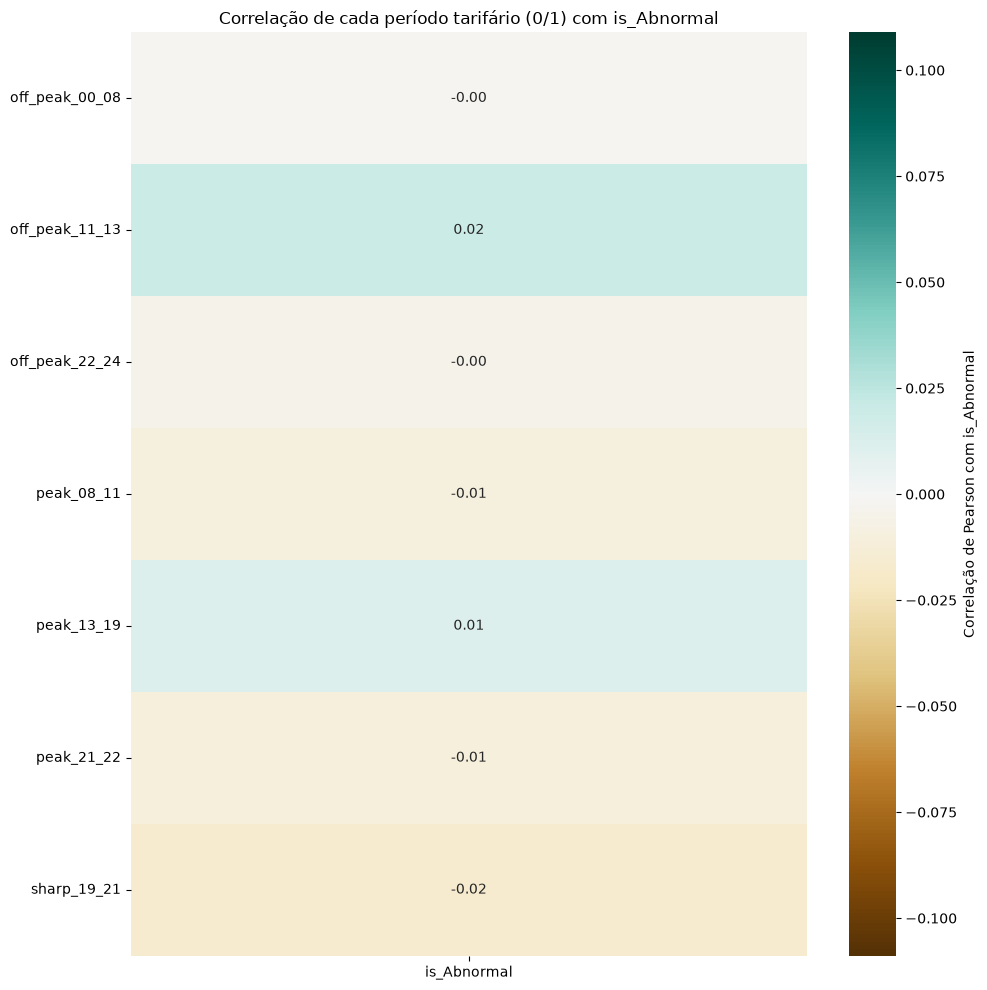

In [916]:
# 4b. Período tarifário (mesma escala de cor da localização)
plt.figure(figsize=(10, 10))
sns.heatmap(corr_periodo, cmap='BrBG', center=0, vmin=-limite, vmax=limite, annot=True, fmt='.2f', cbar_kws={'label': 'Correlação de Pearson com is_Abnormal'})
plt.title('Correlação de cada período tarifário (0/1) com is_Abnormal')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Estabilidade temporal

In [917]:
# Período coberto pelos dados
print('Primeira sessão:', df['Start Time'].min())
print('Última sessão:  ', df['Start Time'].max())

# Resumo mês a mês (pelo mês de início da sessão)
mes = df['Start Time'].dt.to_period('M')
mensal = df.groupby(mes).agg(
    sessoes=('is_Abnormal', 'size'),
    taxa_anomalia=('is_Abnormal', 'mean'),
    usuarios_ativos=('UserID', 'nunique'),
    postos_ativos=('Charging Post ID', 'nunique'),
    pct_novos_usuarios=('is_new_user', 'mean'),
)
# Passar as proporções para %
mensal['taxa_anomalia'] = mensal['taxa_anomalia'] * 100
mensal['pct_novos_usuarios'] = mensal['pct_novos_usuarios'] * 100

mensal.round(1)

Primeira sessão: 2019-12-31 21:27:03
Última sessão:   2021-12-31 23:52:14


,sessoes,taxa_anomalia,usuarios_ativos,postos_ativos,pct_novos_usuarios
Start Time,,,,,
2019-12,17,29.4,16,17,94.1
2020-01,6217,25.0,1963,92,31.4
2020-02,1391,26.3,516,83,23.7
2020-03,6392,24.8,1797,92,20.9
2020-04,11136,22.1,2622,92,15.5
2020-05,15033,19.2,3153,92,12.4
2020-06,17513,16.0,3185,91,9.7
2020-07,22032,18.2,3704,92,8.8
2020-08,25562,20.1,4733,92,10.4


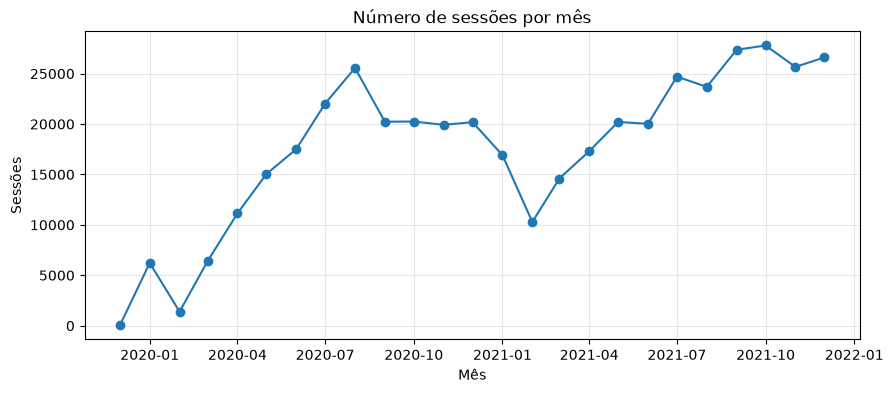

In [918]:
# Número de sessões por mês
x = mensal.index.to_timestamp()

plt.figure(figsize=(10, 4))
plt.plot(x, mensal['sessoes'], marker='o')
plt.title('Número de sessões por mês')
plt.xlabel('Mês')
plt.ylabel('Sessões')
plt.grid(alpha=0.3)
plt.show()

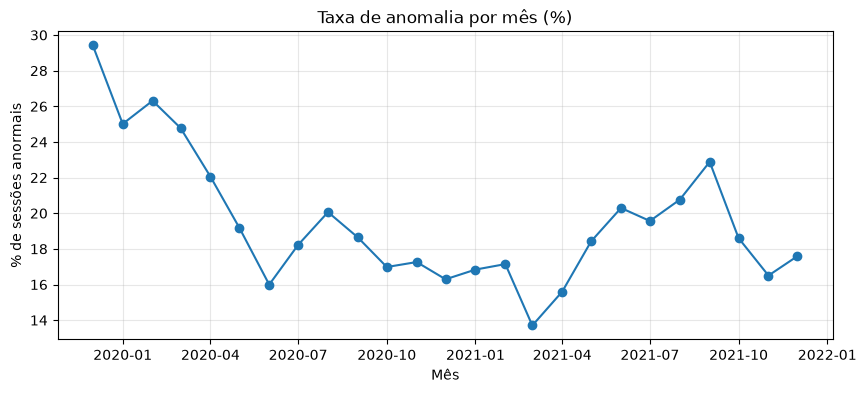

In [919]:
# Taxa de anomalia por mês (%)
plt.figure(figsize=(10, 4))
plt.plot(x, mensal['taxa_anomalia'], marker='o')
plt.title('Taxa de anomalia por mês (%)')
plt.xlabel('Mês')
plt.ylabel('% de sessões anormais')
plt.grid(alpha=0.3)
plt.show()

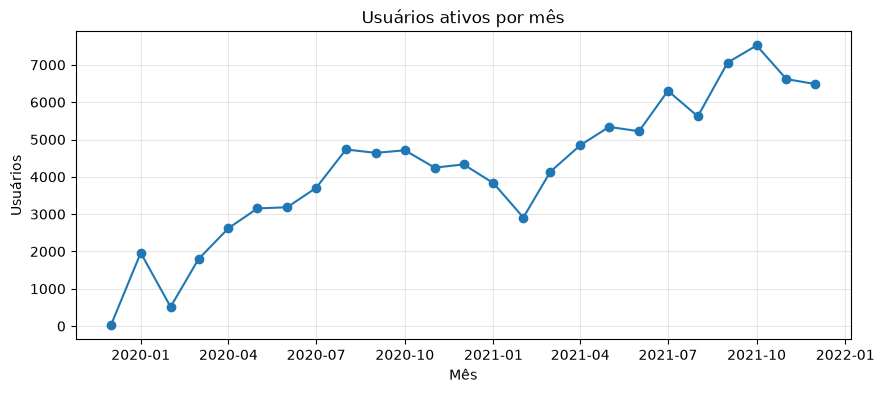

In [920]:
# Usuários ativos por mês
plt.figure(figsize=(10, 4))
plt.plot(x, mensal['usuarios_ativos'], marker='o')
plt.title('Usuários ativos por mês')
plt.xlabel('Mês')
plt.ylabel('Usuários')
plt.grid(alpha=0.3)
plt.show()

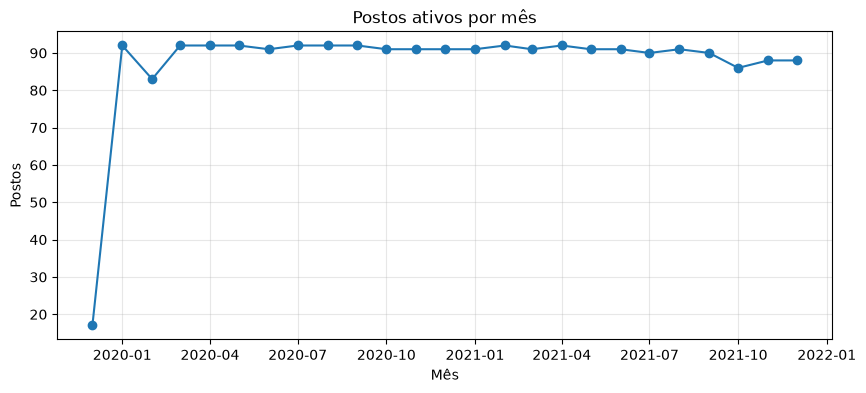

In [921]:
# Postos ativos por mês
plt.figure(figsize=(10, 4))
plt.plot(x, mensal['postos_ativos'], marker='o')
plt.title('Postos ativos por mês')
plt.xlabel('Mês')
plt.ylabel('Postos')
plt.grid(alpha=0.3)
plt.show()

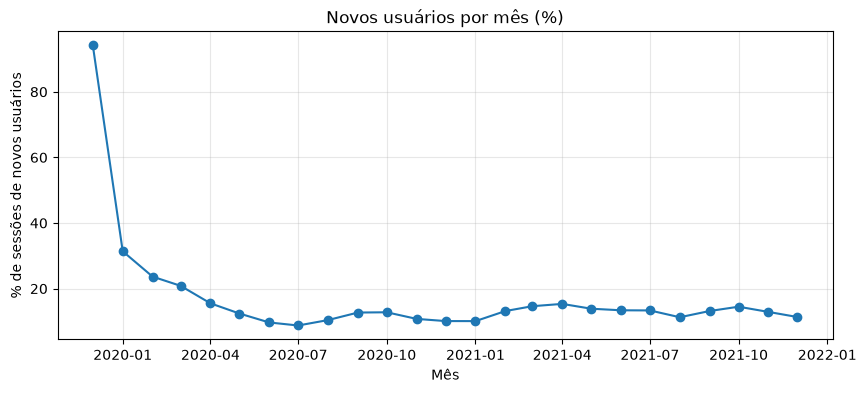

In [922]:
# Novos usuários por mês (%)
plt.figure(figsize=(10, 4))
plt.plot(x, mensal['pct_novos_usuarios'], marker='o')
plt.title('Novos usuários por mês (%)')
plt.xlabel('Mês')
plt.ylabel('% de sessões de novos usuários')
plt.grid(alpha=0.3)
plt.show()

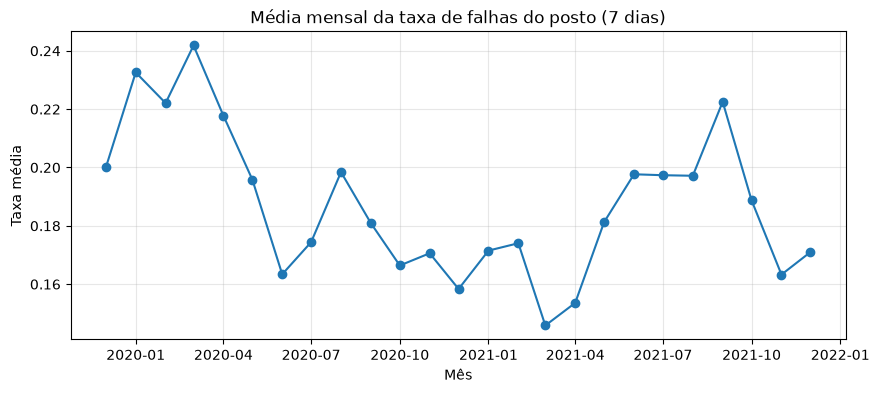

In [923]:
# Média mensal da taxa de falhas do posto (7 dias)
# (a distribuição dos preditores também muda com o tempo?)
media = df.groupby(mes)['post_previous_abnormal_rate_7D'].mean()

plt.figure(figsize=(10, 4))
plt.plot(x, media, marker='o')
plt.title('Média mensal da taxa de falhas do posto (7 dias)')
plt.xlabel('Mês')
plt.ylabel('Taxa média')
plt.grid(alpha=0.3)
plt.show()

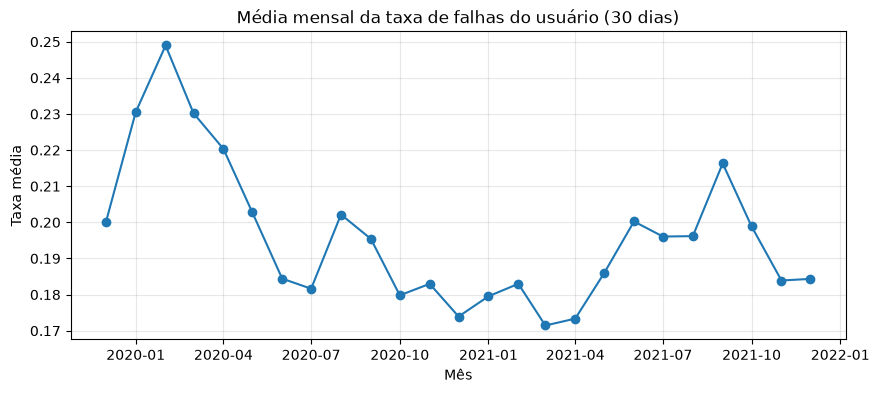

In [924]:
# Média mensal da taxa de falhas do usuário (30 dias)
media = df.groupby(mes)['user_previous_abnormal_rate_30D'].mean()

plt.figure(figsize=(10, 4))
plt.plot(x, media, marker='o')
plt.title('Média mensal da taxa de falhas do usuário (30 dias)')
plt.xlabel('Mês')
plt.ylabel('Taxa média')
plt.grid(alpha=0.3)
plt.show()

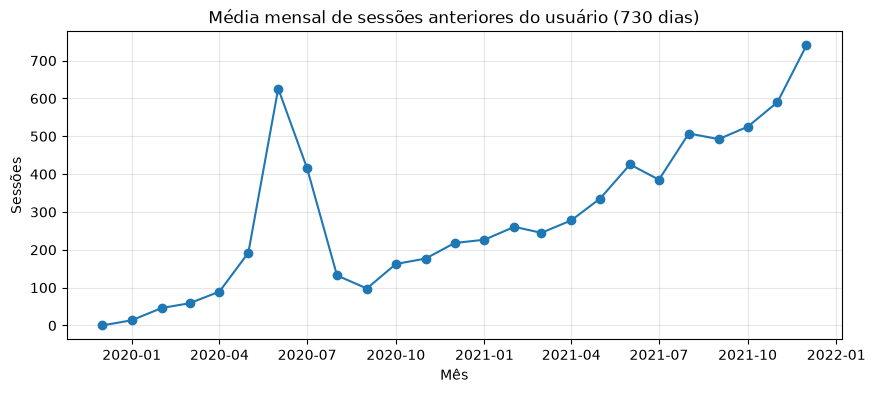

In [925]:
# Média mensal de sessões anteriores do usuário (730 dias)
media = df.groupby(mes)['user_previous_sessions_730D'].mean()

plt.figure(figsize=(10, 4))
plt.plot(x, media, marker='o')
plt.title('Média mensal de sessões anteriores do usuário (730 dias)')
plt.xlabel('Mês')
plt.ylabel('Sessões')
plt.grid(alpha=0.3)
plt.show()

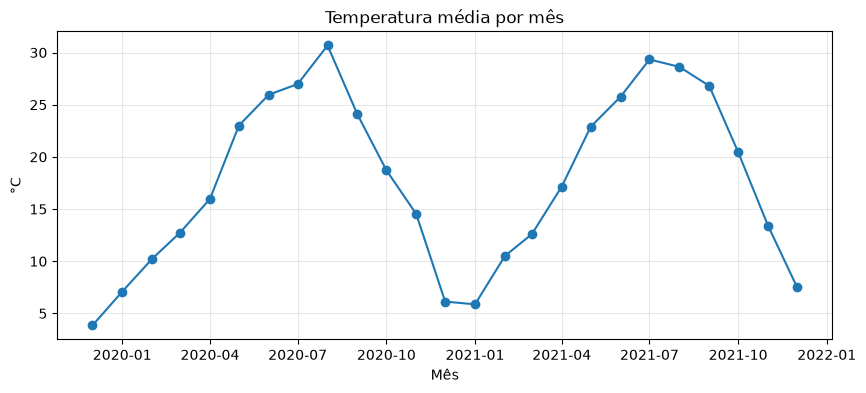

In [926]:
# Temperatura média por mês
media = df.groupby(mes)['Temperature(℃)'].mean()

plt.figure(figsize=(10, 4))
plt.plot(x, media, marker='o')
plt.title('Temperatura média por mês')
plt.xlabel('Mês')
plt.ylabel('°C')
plt.grid(alpha=0.3)
plt.show()